In [2]:
import xarray as xr
import fsspec
import zarr
import dask.array as da
import numpy as np
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

In [9]:
allLevelsFile = '../data/sandy2012-windUV_all_levels_from_250_to_850-rechunked.zarr'
subsetLevelsFile = '../data/sandy2012-windUV_250_500_850.zarr'
sandyCoordsFile = "../data/sandy2012-coords.csv"

allLevelsDs = xr.open_zarr(allLevelsFile, consolidated=False)
subsetLevelsDs = xr.open_zarr(subsetLevelsFile, consolidated=False)
sandyCoords = pd.read_csv(sandyCoordsFile)

In [12]:
sandyCoords["datetime"] = pd.to_datetime(sandyCoords["datetime"])
sandyCoords = sandyCoords.sort_values("datetime").reset_index(drop=True)

sandyCoords["lat"] = sandyCoords["lat"].astype(float)
sandyCoords["lon"] = sandyCoords["lon"].astype(float)
sandyCoords


,datetime,lat,lon
0,2012-10-21 18:00:00,14.3,-77.4
1,2012-10-22 00:00:00,13.9,-77.8
2,2012-10-22 06:00:00,13.5,-78.2
3,2012-10-22 12:00:00,13.1,-78.6
4,2012-10-22 18:00:00,12.7,-78.7
5,2012-10-23 00:00:00,12.6,-78.4
6,2012-10-23 06:00:00,12.9,-78.1
7,2012-10-23 12:00:00,13.4,-77.9
8,2012-10-23 18:00:00,14.0,-77.6
9,2012-10-24 00:00:00,14.7,-77.3


In [54]:
def interp_storm_latlon(storm_df, time):
    t = pd.to_datetime(time)

    dt = storm_df["datetime"].values

    if t.to_datetime64() < dt[0] or t.to_datetime64() > dt[-1]:
        return None

    exact = storm_df.loc[storm_df["datetime"] == t]
    if len(exact) > 0:
        return float(exact["lat"].iloc[0]), float(exact["lon"].iloc[0])

    i = np.searchsorted(dt, t.to_datetime64(), side="right")
    i0, i1 = i - 1, i

    t0 = storm_df["datetime"].iloc[i0]
    t1 = storm_df["datetime"].iloc[i1]

    frac = (t - t0) / (t1 - t0)

    lat0, lat1 = storm_df["lat"].iloc[i0], storm_df["lat"].iloc[i1]
    lon0, lon1 = storm_df["lon"].iloc[i0], storm_df["lon"].iloc[i1]

    lat = float(lat0 + frac * (lat1 - lat0))
    lon = float(lon0 + frac * (lon1 - lon0))

    return lat, lon

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_wind_quiver_single_uv(
    u,
    v,
    lats,
    lons,
    *,
    time=None,                          # only used for storm dot interpolation
    stride: int = 10,
    extent=None,
    max_speed_for_black=None,
    ax=None,
    title: str | None = None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    """
    Core renderer: given u/v + lat/lon arrays for ONE time, plot quiver + coastline +
    optional storm dot at `time` (and +6h dot).
    """
    Lon, Lat = np.meshgrid(lons, lats)

    Lon_s = Lon[::stride, ::stride]
    Lat_s = Lat[::stride, ::stride]
    u_s   = u[::stride, ::stride]
    v_s   = v[::stride, ::stride]

    speed = np.sqrt(u_s**2 + v_s**2)

    if max_speed_for_black is None:
        max_speed_for_black = float(np.nanpercentile(speed, 95)) if np.isfinite(speed).any() else 1.0
        if max_speed_for_black <= 0:
            max_speed_for_black = 1.0

    if ax is None:
        fig = plt.figure(figsize=(6, 4))
        ax = plt.axes(projection=ccrs.PlateCarree())
    else:
        fig = None

    ax.set_facecolor("white")

    if extent is not None:
        lon_min, lon_max, lat_min, lat_max = extent
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

    ax.quiver(
        Lon_s, Lat_s, u_s, v_s, speed,
        transform=ccrs.PlateCarree(),
        cmap="Greys",
        clim=(0.0, max_speed_for_black),
        scale=1500,
        width=0.0012,
        pivot="middle",
    )

    # storm dots (needs time)
    if show_storm_dot and storm_df is not None and time is not None:
        pt = interp_storm_latlon(storm_df, time)
        if pt is not None:
            lat_pt, lon_pt = pt
            ax.scatter(
                [lon_pt], [lat_pt],
                transform=ccrs.PlateCarree(),
                s=storm_dot_size,
                c="red",
                edgecolors="none",
                zorder=10,
            )

            t_next = pd.to_datetime(time) + pd.Timedelta(hours=6)
            pt2 = interp_storm_latlon(storm_df, t_next)
            if pt2 is not None:
                lat2, lon2 = pt2
                ax.scatter(
                    [lon2], [lat2],
                    transform=ccrs.PlateCarree(),
                    s=storm_dot_size,
                    c="#ff9999",
                    edgecolors="none",
                    zorder=10,
                )
                ax.plot(
                    [lon_pt, lon2],
                    [lat_pt, lat2],
                    transform=ccrs.PlateCarree(),
                    color="red",
                    linewidth=1.5,
                    zorder=9,
                )

    if title is not None:
        ax.set_title(title)

    return fig, ax


def plot_wind_quiver_single_from_ds(
    ds,
    pressure_hpa: int,
    time,
    *,
    stride: int = 10,
    extent=None,
    max_speed_for_black=None,
    ax=None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    """
    Convenience wrapper: select u/v from ds at (time, pressure_hpa), then call core UV plotter.
    """
    sel = ds.sel(level=pressure_hpa).sel(time=time)

    u = sel["u"].values
    v = sel["v"].values
    lats = sel["latitude"].values
    lons = sel["longitude"].values

    return plot_wind_quiver_single_uv(
        u,
        v,
        lats,
        lons,
        time=time,
        stride=stride,
        extent=extent,
        max_speed_for_black=max_speed_for_black,
        ax=ax,
        title=f"{pressure_hpa} hPa",
        storm_df=storm_df,
        show_storm_dot=show_storm_dot,
        storm_dot_size=storm_dot_size,
    )


def plot_wind_quiver_levels_side_by_side(
    ds,
    pressure_levels,
    time,
    *,
    stride: int = 10,
    extent=None,
    max_speed_for_black=None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    n = len(pressure_levels)

    fig = plt.figure(figsize=(5 * n, 5))
    axes = []

    for i, lvl in enumerate(pressure_levels, start=1):
        ax = fig.add_subplot(1, n, i, projection=ccrs.PlateCarree())
        axes.append(ax)

        plot_wind_quiver_single_from_ds(
            ds,
            lvl,
            time,
            stride=stride,
            extent=extent,
            max_speed_for_black=max_speed_for_black,
            ax=ax,
            storm_df=storm_df,
            show_storm_dot=show_storm_dot,
            storm_dot_size=storm_dot_size,
        )

    fig.suptitle(f"Wind Quivers — {time}", y=0.88)
    fig.tight_layout(w_pad=0.2)

    return fig, axes


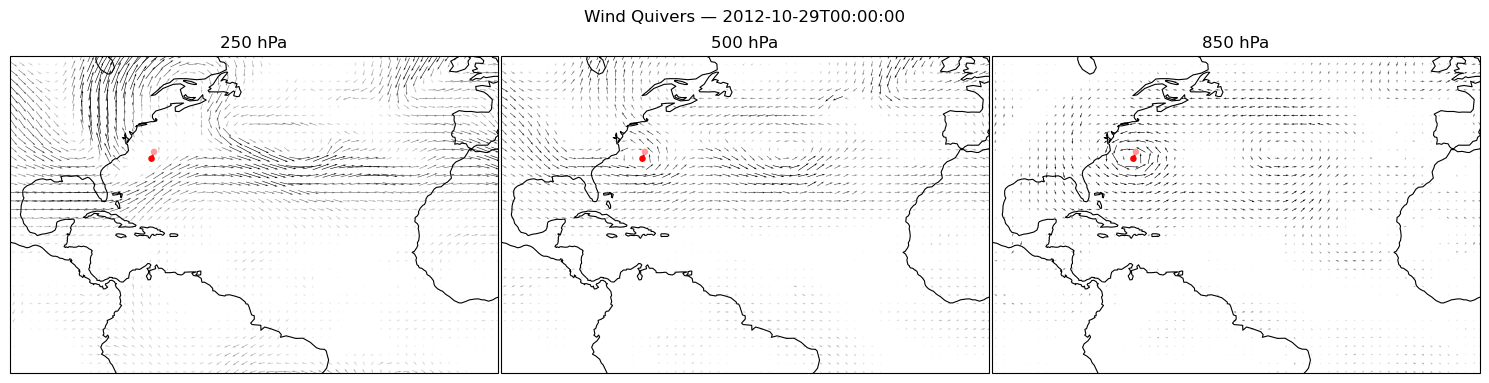

In [55]:
fig, axes = plot_wind_quiver_levels_side_by_side(
    subsetLevelsDs,
    [250, 500, 850],
    "2012-10-29T00:00:00",        
    stride=7,
    extent=(-100, 0, -10, 55),
    storm_df=sandyCoords,       
)
plt.show()


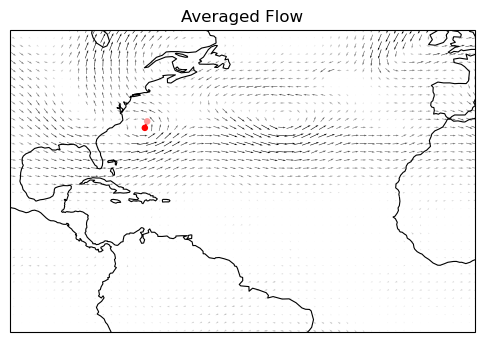

In [57]:
# pick the levels you care about
levels = [250, 500, 850]

# select time + levels
sel = subsetLevelsDs.sel(time="2012-10-29T00:00:00", level=levels)

# average u/v across level -> (latitude, longitude)
u_avg = sel["u"].mean(dim="level").values
v_avg = sel["v"].mean(dim="level").values

# coords (1D arrays)
lats = sel["latitude"].values
lons = sel["longitude"].values

fig, ax = plot_wind_quiver_single_uv(
    u_avg,
    v_avg,
    lats,
    lons,
    time="2012-10-29T00:00:00",
    stride=7,
    extent=(-100, 0, -10, 55),
    storm_df=sandyCoords,
    title='Averaged Flow'
)

plt.show()
